## Configuración para Google Colab
Montamos Google Drive para acceder a los archivos del proyecto.

In [ ]:
# Montamos el drive para poder trabajar con la carpeta
from google.colab import drive
drive.mount('/content/drive')

# Ruta de la carpeta de drive
BASE_PATH = '/content/drive/MyDrive/ActividadEvaluativa1_SantiagoArbelaez_FedericoAlvarez/ActividadEvaluativa3/sea_animals_classification/data/'

# 03. Entrenamiento con MobileNetV2
Este notebook realiza el entrenamiento del modelo MobileNetV2 siguiendo el mismo flujo de dos fases.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

sys.path.append('..')
from utils import preprocessing, augmentation, metrics

RANDOM_STATE = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

## 1. Carga de Datos y Generadores

In [2]:
df = preprocessing.load_data_to_df(BASE_PATH)
df_imb = preprocessing.create_artificial_imbalance(df, random_state=RANDOM_STATE)
train_df, val_df, test_df = preprocessing.split_data(df_imb, random_state=RANDOM_STATE)

train_gen_obj, val_gen_obj = augmentation.get_augmentation_generator(model_type='mobilenet')

train_generator = train_gen_obj.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_generator = val_gen_obj.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_generator = val_gen_obj.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Found 8832 validated image filenames belonging to 23 classes.
Found 1893 validated image filenames belonging to 23 classes.
Found 1893 validated image filenames belonging to 23 classes.


## 2. FASE 1: Transfer Learning Puro

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 541s 2s/step - accuracy: 0.5897 - loss: 1.4219 - val_accuracy: 0.7485 - val_loss: 0.8240
Epoch 2/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 489s 2s/step - accuracy: 0.6937 - loss: 1.0211 - val_accuracy: 0.7649 - val_loss: 0.7635
Epoch 3/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 501s 2s/step - accuracy: 0.7167 - loss: 0.9361 - val_accuracy: 0.7903 - val_loss: 0.6824
Epoch 4/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 507s 2s/step - accuracy: 0.7310 - loss: 0.8683 - val_accuracy: 0.7871 - val_loss: 0.6945
Epoch 5/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 640s 2s/step - accuracy: 0.7425 - loss: 0.8355 - val_accuracy: 0.8082 - val_loss: 0.6756
Epoch 6/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 566s 2s/step - accuracy: 0.7481 - loss: 0.8166 - val_accuracy: 0.8035 - val_loss: 0.6588
Epoch 7/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 627s 2s/step - accuracy: 0.7587 - loss: 0.7864 - val_accuracy: 0.8077 - val_loss: 0.6645
Epoch 8/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 623s 2s/

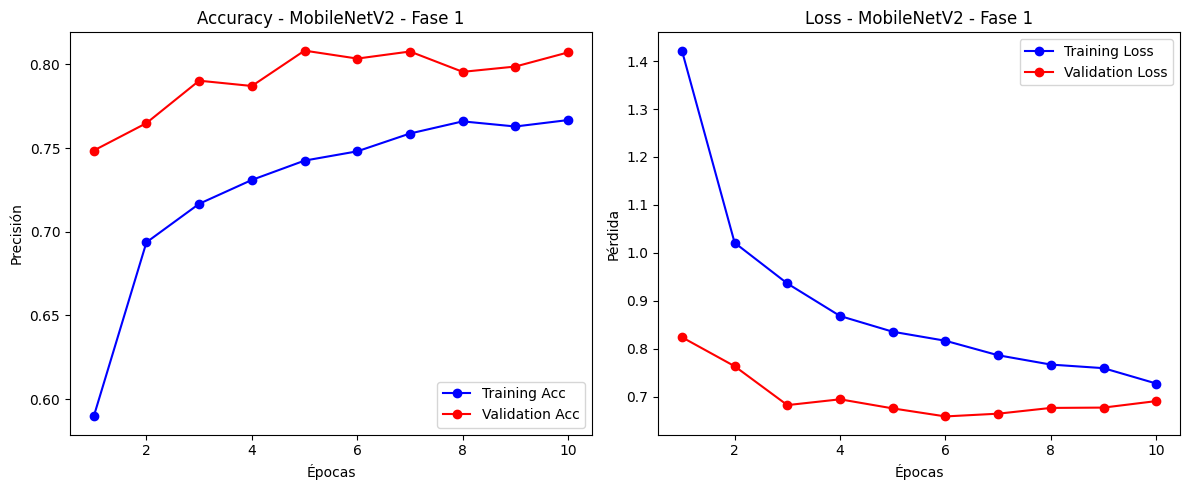

In [3]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(23, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('../models/mobilenet_phase1.keras', save_best_only=True)
]

history_phase1 = model.fit(train_generator, validation_data=val_generator, epochs=10, callbacks=callbacks)
metrics.plot_history(history_phase1, title="MobileNetV2 - Fase 1")

## 3. FASE 2: Fine-Tuning

Epoch 1/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 648s 2s/step - accuracy: 0.7214 - loss: 0.9194 - val_accuracy: 0.8119 - val_loss: 0.6585
Epoch 2/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 630s 2s/step - accuracy: 0.7472 - loss: 0.8392 - val_accuracy: 0.8125 - val_loss: 0.6430
Epoch 3/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 556s 2s/step - accuracy: 0.7545 - loss: 0.8001 - val_accuracy: 0.8104 - val_loss: 0.6537
Epoch 4/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 548s 2s/step - accuracy: 0.7613 - loss: 0.7593 - val_accuracy: 0.8177 - val_loss: 0.6439
Epoch 5/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 569s 2s/step - accuracy: 0.7636 - loss: 0.7699 - val_accuracy: 0.8072 - val_loss: 0.6474
Epoch 6/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 558s 2s/step - accuracy: 0.7729 - loss: 0.7422 - val_accuracy: 0.8093 - val_loss: 0.6496
Epoch 7/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 573s 2s/step - accuracy: 0.7686 - loss: 0.7337 - val_accuracy: 0.8156 - val_loss: 0.6273
Epoch 8/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 712s 3s/step - accuracy: 0.7755 - loss: 0.7282 - val_accu

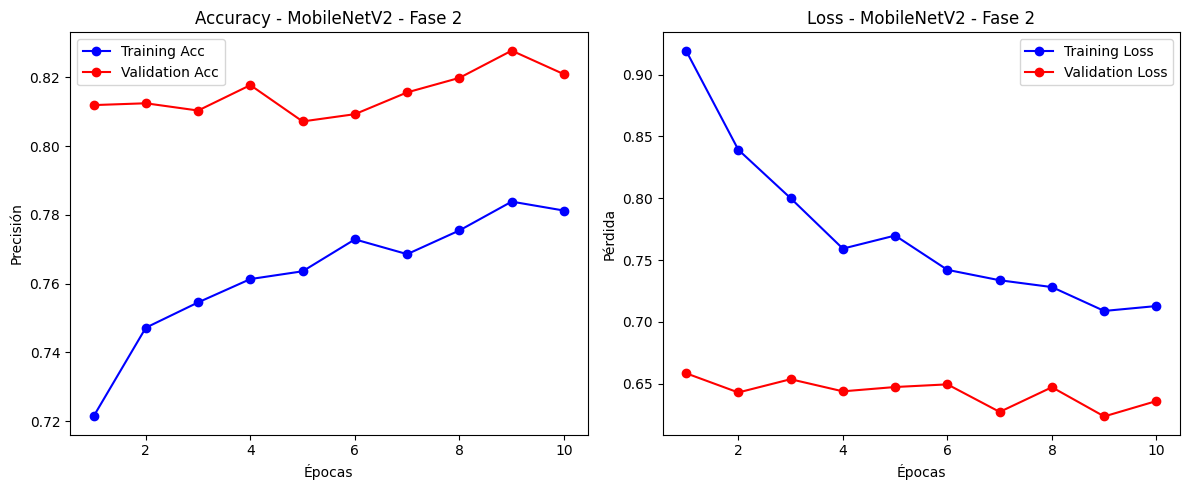

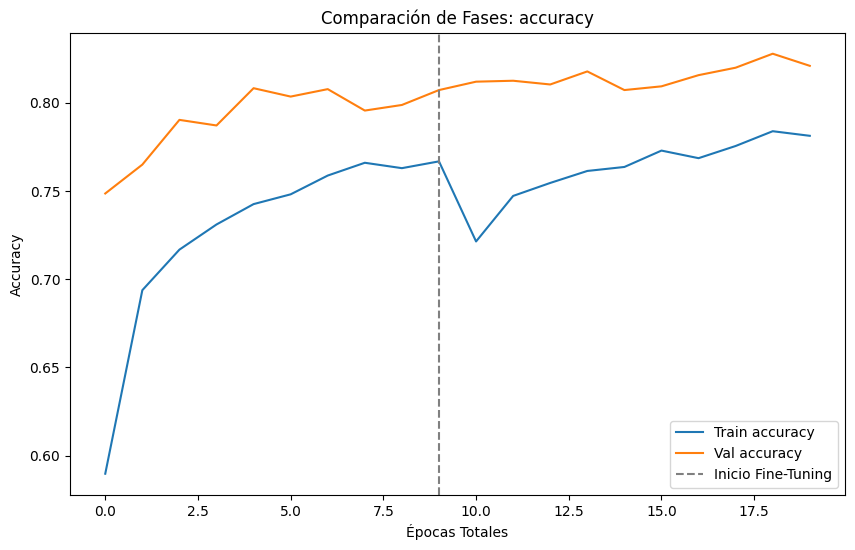

In [4]:
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_ft = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('../models/mobilenet_best.keras', save_best_only=True)
]

history_phase2 = model.fit(train_generator, validation_data=val_generator, epochs=10, callbacks=callbacks_ft)
metrics.plot_history(history_phase2, title="MobileNetV2 - Fase 2")
metrics.compare_phases(history_phase1, history_phase2)

## 4. Evaluación y Experimentos

60/60 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step


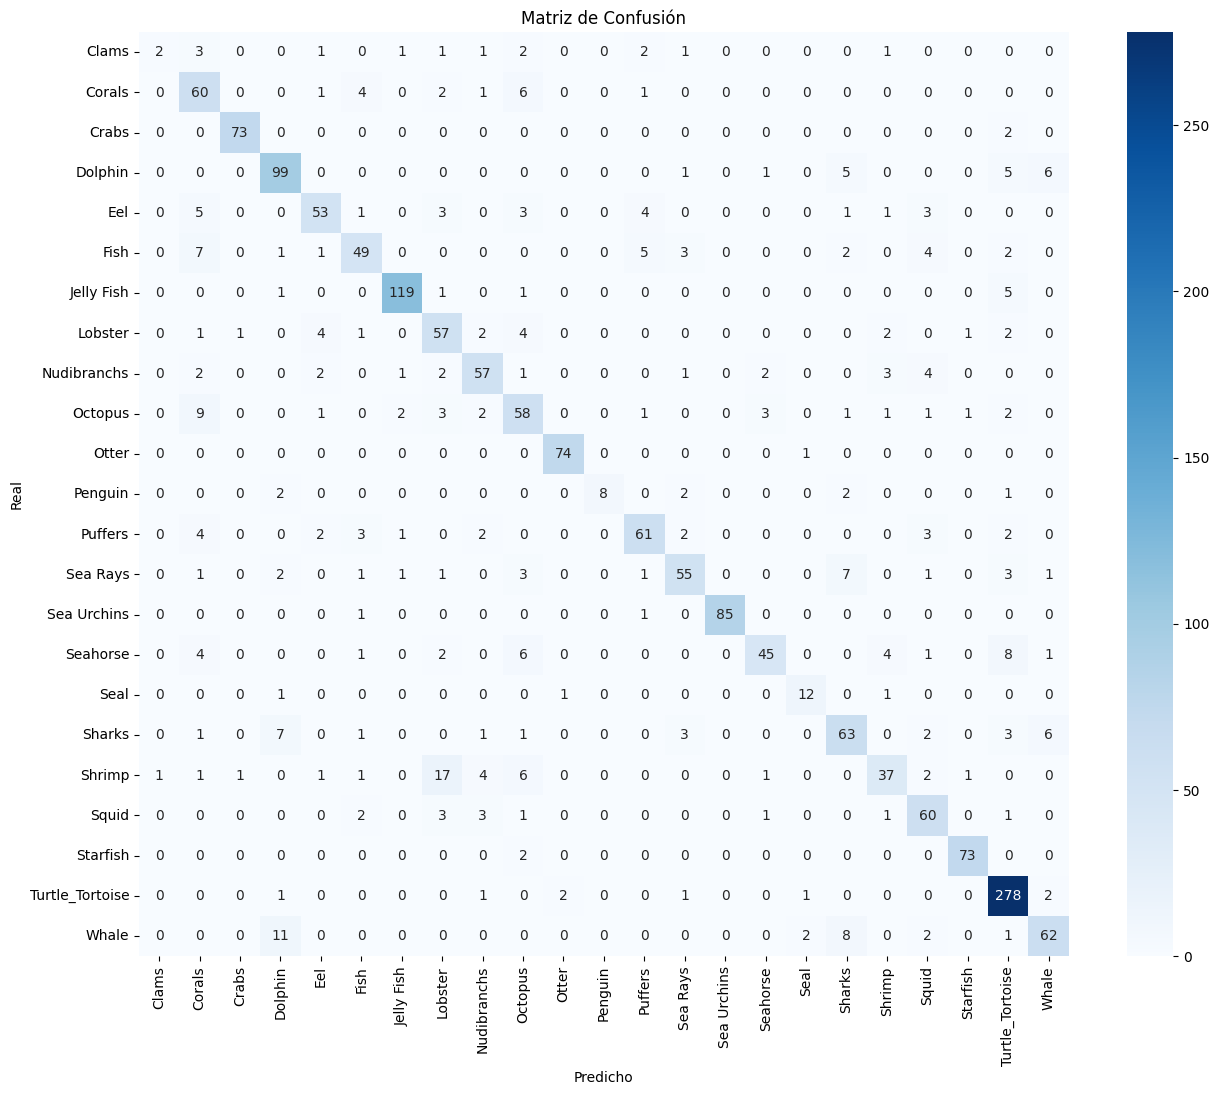

                 precision    recall  f1-score   support

          Clams       0.67      0.13      0.22        15
         Corals       0.61      0.80      0.69        75
          Crabs       0.97      0.97      0.97        75
        Dolphin       0.79      0.85      0.82       117
            Eel       0.80      0.72      0.76        74
           Fish       0.75      0.66      0.71        74
     Jelly Fish       0.95      0.94      0.94       127
        Lobster       0.62      0.76      0.68        75
    Nudibranchs       0.77      0.76      0.77        75
        Octopus       0.62      0.68      0.65        85
          Otter       0.96      0.99      0.97        75
        Penguin       1.00      0.53      0.70        15
        Puffers       0.80      0.76      0.78        80
       Sea Rays       0.80      0.71      0.75        77
    Sea Urchins       1.00      0.98      0.99        87
       Seahorse       0.85      0.62      0.72        72
           Seal       0.75    

In [5]:
y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)
classes = list(test_generator.class_indices.keys())

metrics.plot_confusion_matrix(y_true, y_pred, classes)
metrics.print_classification_report(y_true, y_pred, classes)
metrics.analyze_overfitting(history_phase2)

np.save(RESULTS_PATH + 'mobilenet_history.npy', history_phase2.history)